# BTCUSDT Data Exploration

**Stage 2 — Minimal Historical Market Analytics**

Explore the existing Bybit spot BTCUSDT hourly snapshot: **2025-10-01 00:00 UTC through 2026-09-30 23:00 UTC** (candle opening times). The requested end is 2026-10-01 00:00 UTC, excluded.

This notebook focuses on returns, volatility, volume, extreme movements, and a BTC buy-and-hold drawdown. These are historical descriptions, not predictions or trading recommendations. No strategy, bot backtest, or position sizing is implemented.

The six-column raw snapshot stays unchanged. All derived columns live only in the notebook's in-memory analysis DataFrame. No processed dataset is created.

## 1. Imports

Use the existing pandas, NumPy, Matplotlib, and Jupyter stack. The project uses a `src/` layout, so we add that directory to Python's import path and call the existing loading and validation functions. API code remains outside the notebook.

The current virtual environment can emit an urllib3/LibreSSL compatibility warning when the loader imports requests. It is not suppressed; reading the existing CSV makes no HTTP request.

In [1]:
from pathlib import Path
import sys

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "trading_lab").is_dir()
)
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import (
    download_ohlcv,
    invalid_ohlc_mask,
    load_ohlcv_csv,
    save_ohlcv,
    validate_ohlcv,
)

Matplotlib is building the font cache; this may take a moment.


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Load and Inspect the Existing Snapshot

Load the local CSV with the reusable project code. Download only if the snapshot is missing. The fixed period and saved snapshot keep research inputs consistent. `save_ohlcv` refuses to overwrite existing raw files.

The loader restores UTC timestamps and numeric columns, sorts downloaded candles chronologically, and validates the requested hourly coverage. Invalid local data raises an error rather than being silently repaired. Bybit's JSON conversion and backward pagination remain in the existing reusable loader and exchange adapter.

In [2]:
START = "2025-10-01T00:00:00Z"
END = "2026-10-01T00:00:00Z"  # Exclusive: the last candle opens one hour earlier.
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"

if CSV_PATH.exists():
    raw_df = load_ohlcv_csv(CSV_PATH, interval="60", start=START, end=END)
    print("Loaded local snapshot:", CSV_PATH)
else:
    raw_df = download_ohlcv(
        start=START, end=END, symbol="BTCUSDT", category="spot", interval="60"
    )
    save_ohlcv(raw_df, CSV_PATH)
    print("Downloaded and saved:", CSV_PATH)
    print("API pages:", raw_df.attrs["pages_downloaded"])
    print("Identical duplicates removed:", raw_df.attrs["duplicate_rows_removed"])

Loaded local snapshot: /Users/romankondratenko/trading-lab/Trading Lab/data/raw/BTCUSDT_1h.csv


In [3]:
print("Rows:", len(raw_df))
print("First candle:", raw_df["timestamp"].min())
print("Last candle:", raw_df["timestamp"].max())
print("Columns:", raw_df.columns.tolist())
print("Shape (rows, columns):", raw_df.shape)
display(raw_df.head())
display(raw_df.tail())

Rows: 8760
First candle: 2025-10-01 00:00:00+00:00
Last candle: 2026-09-30 23:00:00+00:00
Columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']
Shape (rows, columns): (8760, 6)


,timestamp,open,high,low,close,volume
0,2025-10-01 00:00:00+00:00,114051.1,114300.3,113962.3,114241.0,256.712737
1,2025-10-01 01:00:00+00:00,114241.0,114550.0,114142.2,114549.4,240.479371
2,2025-10-01 02:00:00+00:00,114549.4,114551.9,114252.4,114275.5,219.500905
3,2025-10-01 03:00:00+00:00,114275.5,114533.5,114100.1,114178.1,296.903591
4,2025-10-01 04:00:00+00:00,114178.1,114710.2,114140.7,114291.0,280.776000


,timestamp,open,high,low,close,volume
8755,2026-09-30 19:00:00+00:00,83944.6,83960.7,83491.2,83595.4,260.379820
8756,2026-09-30 20:00:00+00:00,83595.4,83779.4,83522.7,83670.5,139.220277
8757,2026-09-30 21:00:00+00:00,83670.5,83820.2,83670.5,83758.6,91.674001
8758,2026-09-30 22:00:00+00:00,83758.6,83840.8,83575.1,83683.2,81.231509
8759,2026-09-30 23:00:00+00:00,83683.2,83836.7,83524.3,83616.2,163.752491


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timestamp  8760 non-null   datetime64[ns, UTC]
 1   open       8760 non-null   float64            
 2   high       8760 non-null   float64            
 3   low        8760 non-null   float64            
 4   close      8760 non-null   float64            
 5   volume     8760 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(5)
memory usage: 410.8 KB


In [5]:
raw_df.dtypes

timestamp    datetime64[ns, UTC]
open                     float64
high                     float64
low                      float64
close                    float64
volume                   float64
dtype: object

## 3. Basic Data Quality

Confirm missing values, duplicate timestamps, chronological order, hourly continuity, and OHLC validity before calculating returns. A high must be at least open, close, and low; a low must be at most open, close, and high. Prices must be positive and volume non-negative.

The reusable validator already rejects invalid datasets. These examples make its checks visible for learning; no raw rows are removed or filled.

In [6]:
raw_df.isna().sum()

timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64

In [7]:
duplicate_rows = raw_df[raw_df["timestamp"].duplicated(keep=False)]
invalid_rows = raw_df.loc[invalid_ohlc_mask(raw_df)]
expected_hours = pd.date_range(START, END, freq="h", inclusive="left")
missing_hours = expected_hours.difference(pd.DatetimeIndex(raw_df["timestamp"]))

print("Duplicate timestamps:", raw_df["timestamp"].duplicated().sum())
print("Chronological order:", raw_df["timestamp"].is_monotonic_increasing)
print("Missing hourly candles:", len(missing_hours))
print("Invalid OHLC/volume rows:", len(invalid_rows))
display(duplicate_rows)
display(invalid_rows)
display(missing_hours[:10])

quality = validate_ohlcv(raw_df, interval="60", start=START, end=END)
quality

Duplicate timestamps: 0
Chronological order: True
Missing hourly candles: 0
Invalid OHLC/volume rows: 0


,timestamp,open,high,low,close,volume


,timestamp,open,high,low,close,volume


DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='h')

{'rows': 8760,
 'earliest_timestamp': Timestamp('2025-10-01 00:00:00+0000', tz='UTC'),
 'latest_timestamp': Timestamp('2026-09-30 23:00:00+0000', tz='UTC'),
 'missing_values': {'timestamp': 0,
  'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'volume': 0},
 'duplicate_timestamps': 0,
 'chronological': True,
 'invalid_ohlc_rows': 0,
 'missing_candles': 0}

## 4. Close Price

Plot the full dataset's hourly closing price in USDT. The timestamps label candle opening times. This shows the price path without adding technical indicators.

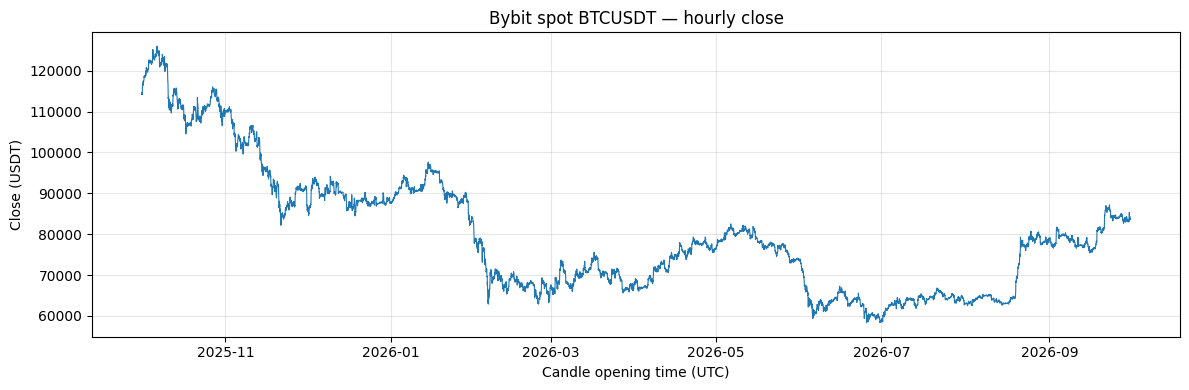

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw_df["timestamp"], raw_df["close"], linewidth=0.8)
ax.set(title="Bybit spot BTCUSDT — hourly close", xlabel="Candle opening time (UTC)", ylabel="Close (USDT)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Simple Hourly Returns

A simple return is `current_close / previous_close - 1`. It describes the proportional change between consecutive hourly closes: `0.01` means **+1%**, and `-0.01` means **-1%**.

Returns make changes comparable across different price levels. A 1,000-USDT move has a different proportional size at 50,000 than at 100,000 USDT.

Make a separate copy for analysis, then use `pct_change(fill_method=None)`. The first return is naturally missing because there is no previous close in this snapshot. We do not fill it or alter the raw data.

In [9]:
df = raw_df.copy()
df["simple_return"] = df["close"].pct_change(fill_method=None)

print("Valid hourly returns:", df["simple_return"].count())
print("Missing returns (expected first row only):", df["simple_return"].isna().sum())
df[["timestamp", "close", "simple_return"]].head()

Valid hourly returns: 8759
Missing returns (expected first row only): 1


,timestamp,close,simple_return
0,2025-10-01 00:00:00+00:00,114241.0,NaN
1,2025-10-01 01:00:00+00:00,114549.4,0.002700
2,2025-10-01 02:00:00+00:00,114275.5,-0.002391
3,2025-10-01 03:00:00+00:00,114178.1,-0.000852
4,2025-10-01 04:00:00+00:00,114291.0,0.000989


## 6. Log Returns

A log return is the natural logarithm of the price ratio: `log(current_close / previous_close)`. `shift(1)` aligns each row with the preceding close, and NumPy's `log` performs the calculation.

Simple and log returns are close for small changes, but are not identical. Log returns add across consecutive periods; simple returns compound by multiplication. This makes log returns common in financial statistics. A log return is not an exact simple percentage return. Its first row is also naturally missing.

In [10]:
previous_close = df["close"].shift(1)
price_ratio = df["close"] / previous_close
df["log_return"] = np.log(price_ratio)

df[["timestamp", "simple_return", "log_return"]].head()

,timestamp,simple_return,log_return
0,2025-10-01 00:00:00+00:00,NaN,NaN
1,2025-10-01 01:00:00+00:00,0.002700,0.002696
2,2025-10-01 02:00:00+00:00,-0.002391,-0.002394
3,2025-10-01 03:00:00+00:00,-0.000852,-0.000853
4,2025-10-01 04:00:00+00:00,0.000989,0.000988


## 7. Hourly Return Statistics

Use the 8,759 valid simple returns. `dropna()` below excludes only the undefined first derived return, not any raw candle.

- **Mean:** the arithmetic average of hourly returns. It is not a compounded total return or a reliable forecast.
- **Median:** the middle observation after sorting, less sensitive to extremes than the mean.
- **Variance:** squared deviations from the mean, summed and divided by `n - 1` here (`ddof=1`, sample variance). Its units are squared decimal returns.
- **Standard deviation:** the square root of variance, in the same units as returns. It describes spread, not a bound on possible movements.
- **Percentiles:** thresholds below which the specified proportion of observed returns lies.

The table uses decimal returns (`0.01 = 1%`); variance alone has squared units. No annualization is performed. A tiny historical mean should not be treated as evidence of a predictable future direction.

In [11]:
hourly_returns = df["simple_return"].dropna()
return_statistics = pd.Series({
    "Mean": hourly_returns.mean(),
    "Median": hourly_returns.median(),
    "Variance (sample, ddof=1)": hourly_returns.var(ddof=1),
    "Standard deviation (sample, ddof=1)": hourly_returns.std(ddof=1),
    "Minimum": hourly_returns.min(),
    "Maximum": hourly_returns.max(),
    "5th percentile": hourly_returns.quantile(0.05),
    "25th percentile": hourly_returns.quantile(0.25),
    "75th percentile": hourly_returns.quantile(0.75),
    "95th percentile": hourly_returns.quantile(0.95),
}, name="Value (decimal; variance squared)")

display(return_statistics.to_frame().style.format("{:.10f}"))
print(f"Mean hourly return: {hourly_returns.mean():.6%}")
print(f"Median hourly return: {hourly_returns.median():.6%}")
print(f"Hourly return standard deviation: {hourly_returns.std(ddof=1):.6%}")

,Value (decimal; variance squared)
Mean,-0.0000246214
Median,-0.0000046858
"Variance (sample, ddof=1)",0.0000220080
"Standard deviation (sample, ddof=1)",0.0046912660
Minimum,-0.0479463463
Maximum,0.0395809098
5th percentile,-0.0069493408
25th percentile,-0.0020137952
75th percentile,0.0019761348
95th percentile,0.0069781431


Mean hourly return: -0.002462%
Median hourly return: -0.000469%
Hourly return standard deviation: 0.469127%


## 8. Return Distribution

Plot the observed hourly returns as percentages. Bins count how many observations fall into each range; the zero line marks no close-to-close change. We keep all extreme observations in the histogram.

Most returns in this snapshot cluster near zero. The tails include less common, much larger movements. A histogram describes concentration, spread, and tails; it does not establish a normal distribution or predict future extremes.

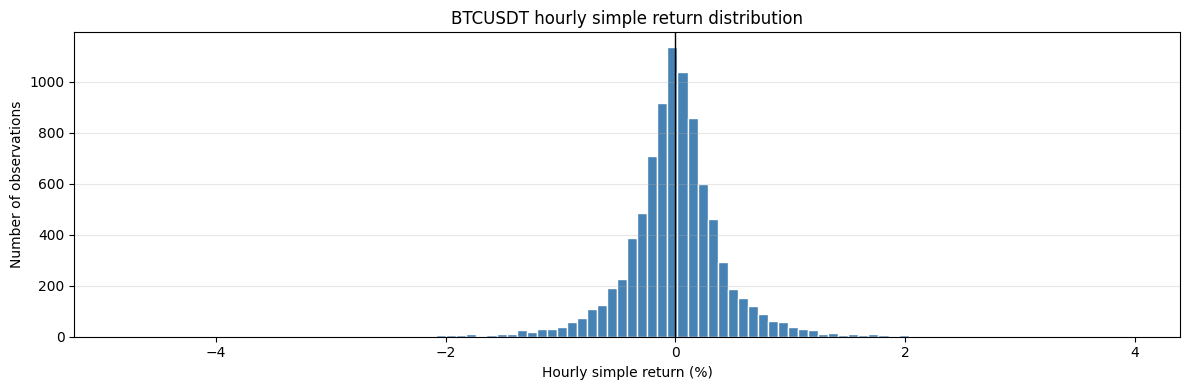

Returns within -1% to +1%: 95.56%
Returns exceeding 3% in absolute size: 9


In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(hourly_returns * 100, bins=100, color="steelblue", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set(title="BTCUSDT hourly simple return distribution", xlabel="Hourly simple return (%)", ylabel="Number of observations")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

within_one_percent = hourly_returns.abs().le(0.01).mean()
beyond_three_percent = hourly_returns.abs().gt(0.03).sum()
print(f"Returns within -1% to +1%: {within_one_percent:.2%}")
print("Returns exceeding 3% in absolute size:", beyond_three_percent)

## 9. Rolling Volatility

Rolling volatility is the standard deviation of hourly returns inside a moving, trailing window. Use 24 observations for approximately one day and 168 for seven days. These remain **hourly-return standard deviations estimated over those windows**, not daily or weekly compounded-return volatility.

Require a full window using `min_periods`. Because the first return is undefined, the first 24 and 168 rows respectively have no volatility estimate. These warm-up NaNs are expected and are not defects in the raw dataset.

Changing volatility means the typical spread of recent returns changes. A future risk manager could reduce allowed position size when volatility rises, and potentially permit a larger size when it falls, subject to other risk limits. No position sizing or annualization is implemented here.

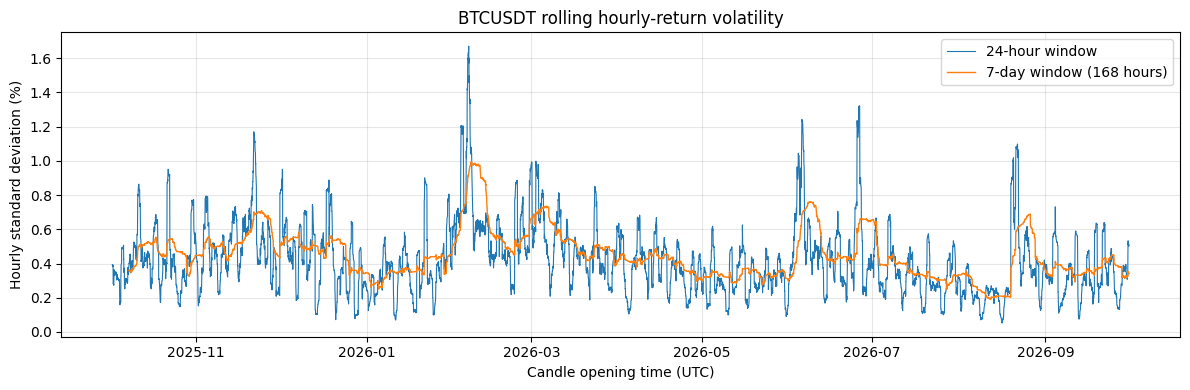

Expected warm-up NaNs:
volatility_24h     24
volatility_7d     168
dtype: int64


,volatility_24h,volatility_7d
count,8736.000000,8592.000000
mean,0.004207,0.004504
std,0.002074,0.001373
min,0.000530,0.001910
25%,0.002766,0.003497
50%,0.003931,0.004305
75%,0.005115,0.005199
max,0.016704,0.009961


In [13]:
df["volatility_24h"] = df["simple_return"].rolling(
    window=24, min_periods=24
).std(ddof=1)
df["volatility_7d"] = df["simple_return"].rolling(
    window=168, min_periods=168
).std(ddof=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["timestamp"], df["volatility_24h"] * 100, label="24-hour window", linewidth=0.8)
ax.plot(df["timestamp"], df["volatility_7d"] * 100, label="7-day window (168 hours)", linewidth=1)
ax.set(title="BTCUSDT rolling hourly-return volatility", xlabel="Candle opening time (UTC)", ylabel="Hourly standard deviation (%)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("Expected warm-up NaNs:")
print(df[["volatility_24h", "volatility_7d"]].isna().sum())
display(df[["volatility_24h", "volatility_7d"]].describe())

In [14]:
peak_24h = df.loc[df["volatility_24h"].idxmax(), ["timestamp", "volatility_24h"]]
peak_7d = df.loc[df["volatility_7d"].idxmax(), ["timestamp", "volatility_7d"]]
print("Highest 24-hour-window estimate:", peak_24h["timestamp"], f"{peak_24h['volatility_24h']:.4%}")
print("Highest 7-day-window estimate:", peak_7d["timestamp"], f"{peak_7d['volatility_7d']:.4%}")

Highest 24-hour-window estimate: 2026-02-06 14:00:00+00:00 1.6704%
Highest 7-day-window estimate: 2026-02-07 13:00:00+00:00 0.9961%


## 10. Volume

Volume measures how many BTC traded during each hourly candle. `describe()` summarizes its distribution; the chart shows when activity was unusually large. `nlargest(10, "volume")` selects the ten largest observed volumes without deleting them from the analysis.

Compare their close-to-close returns descriptively. Large volume can accompany either rising or falling prices, and high volume need not imply a large net hourly return. This table cannot show that volume causes price movements.

In [15]:
df["volume"].describe()

count    8760.000000
mean      399.856328
std       339.882760
min        16.659988
25%       191.253882
50%       303.670497
75%       499.002103
max      7196.330230
Name: volume, dtype: float64

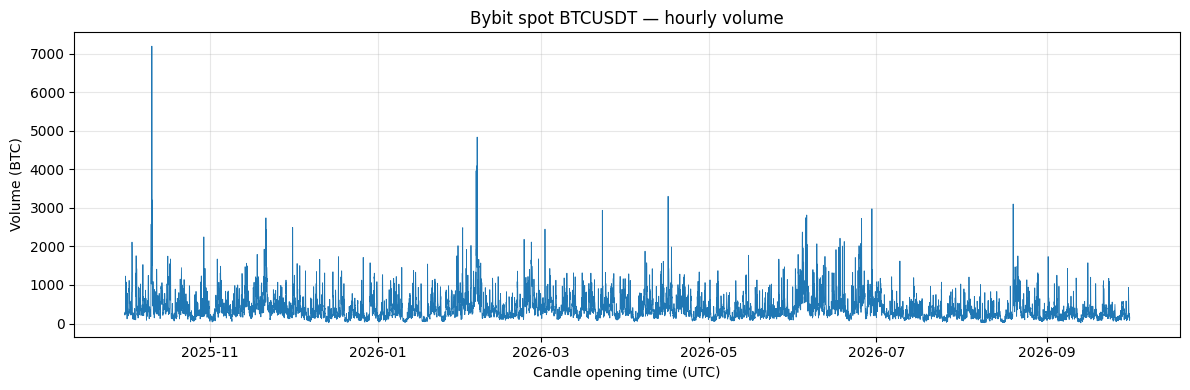

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["timestamp"], df["volume"], linewidth=0.6)
ax.set(title="Bybit spot BTCUSDT — hourly volume", xlabel="Candle opening time (UTC)", ylabel="Volume (BTC)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [17]:
largest_volume = df.nlargest(10, "volume")[
    ["timestamp", "close", "volume", "simple_return"]
]
display(largest_volume.style.format({
    "close": "{:.2f}", "volume": "{:.6f}", "simple_return": "{:.4%}"
}))
print("Of these ten candles, count with at least a 1% absolute return:",
      largest_volume["simple_return"].abs().ge(0.01).sum())

,timestamp,close,volume,simple_return
237,2025-10-10 21:00:00+00:00,113233.20,7196.330230,-0.9193%
3072,2026-02-06 00:00:00+00:00,63506.20,4836.882341,0.9654%
3068,2026-02-05 20:00:00+00:00,63764.00,4088.640897,-2.2912%
3063,2026-02-05 15:00:00+00:00,67479.30,3964.013093,-2.7760%
4736,2026-04-16 08:00:00+00:00,74674.00,3300.665358,-0.0478%
242,2025-10-11 02:00:00+00:00,113192.10,3202.366441,1.9594%
238,2025-10-10 22:00:00+00:00,113523.30,3148.630393,0.2562%
7743,2026-08-19 15:00:00+00:00,68543.00,3100.991994,3.9581%
6512,2026-06-29 08:00:00+00:00,59839.10,2977.587103,-0.2781%
236,2025-10-10 20:00:00+00:00,114283.80,2950.830550,-2.0322%


Of these ten candles, count with at least a 1% absolute return: 5


## 11. Extreme Hourly Movements

Select the five largest positive and five largest negative simple returns. Show their candle opening timestamps, closing prices, returns, and BTC volumes. These observations stay in the dataset and all calculations.

The tables describe the size of extremes in this snapshot. They are not estimates of the largest possible future move, and the timestamp labels the candle's start rather than its close.

In [18]:
extreme_columns = ["timestamp", "close", "simple_return", "volume"]
largest_positive = df.nlargest(5, "simple_return")[extreme_columns]
largest_negative = df.nsmallest(5, "simple_return")[extreme_columns]

print("Five largest positive hourly returns:")
display(largest_positive.style.format({
    "close": "{:.2f}", "simple_return": "{:+.4%}", "volume": "{:.6f}"
}))
print("Five largest negative hourly returns:")
display(largest_negative.style.format({
    "close": "{:.2f}", "simple_return": "{:+.4%}", "volume": "{:.6f}"
}))

Five largest positive hourly returns:


,timestamp,close,simple_return,volume
7743,2026-08-19 15:00:00+00:00,68543.00,+3.9581%,3100.991994
7784,2026-08-21 08:00:00+00:00,79275.90,+3.8714%,1753.385019
494,2025-10-21 14:00:00+00:00,112199.90,+3.4816%,1358.660870
3073,2026-02-06 01:00:00+00:00,65716.20,+3.4800%,1762.687610
3663,2026-03-02 15:00:00+00:00,69123.60,+2.8976%,2448.802373


Five largest negative hourly returns:


,timestamp,close,simple_return,volume
6421,2026-06-25 13:00:00+00:00,58301.10,-4.7946%,2729.103553
1464,2025-12-01 00:00:00+00:00,86994.20,-3.7167%,2492.261879
3606,2026-02-28 06:00:00+00:00,63212.50,-3.6167%,1676.312871
3481,2026-02-23 01:00:00+00:00,64422.50,-3.4581%,2184.676889
3065,2026-02-05 17:00:00+00:00,66175.10,-3.1060%,1936.780202


## 12. BTC Buy-and-Hold Drawdown

- **Equity curve:** a price-based index starting at 1.0 at the first close. Multiplying successive `(1 + simple_return)` values tracks the change in value from holding BTC.
- **Running peak:** the highest equity value reached so far, calculated with `cummax()`.
- **Drawdown:** `equity / running_peak - 1`. It is zero at a new peak and negative below that peak.
- **Maximum drawdown:** the most negative observed drawdown, the largest peak-to-subsequent-trough decline in this index.

Only for index initialization, set the first undefined derived return to zero in a temporary copy; its index value is therefore 1.0. This does not repair or modify raw data.

This is BTC buy-and-hold price analysis, **not a trading strategy or a bot backtest**. Drawdown is measured at candle closes; intrahour lows are not part of this calculation.

Maximum observed close-based drawdown: -53.7338%
Trough candle opening time: 2026-06-25 13:00:00+00:00


,timestamp,equity,running_peak,drawdown
0,2025-10-01 00:00:00+00:00,1.000000,1.0000,0.000000
1,2025-10-01 01:00:00+00:00,1.002700,1.0027,0.000000
2,2025-10-01 02:00:00+00:00,1.000302,1.0027,-0.002391
3,2025-10-01 03:00:00+00:00,0.999449,1.0027,-0.003241
4,2025-10-01 04:00:00+00:00,1.000438,1.0027,-0.002256


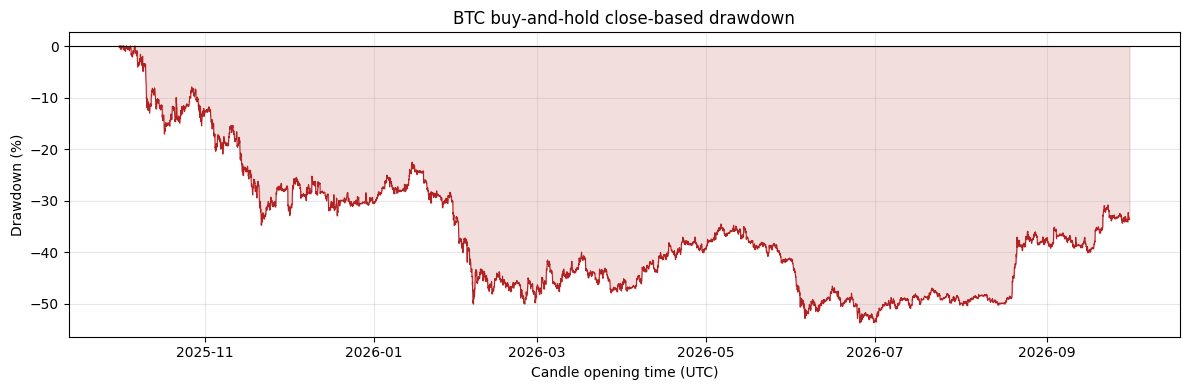

In [19]:
index_returns = df["simple_return"].copy()
index_returns.iloc[0] = 0.0  # Establish the index at the first observed close.
df["equity"] = (1.0 + index_returns).cumprod()
df["running_peak"] = df["equity"].cummax()
df["drawdown"] = df["equity"] / df["running_peak"] - 1.0

maximum_drawdown = df["drawdown"].min()
maximum_drawdown_timestamp = df.loc[df["drawdown"].idxmin(), "timestamp"]
print(f"Maximum observed close-based drawdown: {maximum_drawdown:.4%}")
print("Trough candle opening time:", maximum_drawdown_timestamp)
display(df[["timestamp", "equity", "running_peak", "drawdown"]].head())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["timestamp"], df["drawdown"] * 100, color="firebrick", linewidth=0.8)
ax.fill_between(df["timestamp"], df["drawdown"] * 100, 0, color="firebrick", alpha=0.15)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(title="BTC buy-and-hold close-based drawdown", xlabel="Candle opening time (UTC)", ylabel="Drawdown (%)")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Check the Derived Calculations

These small assertions check interpretation errors: returns have exactly one undefined value, rolling estimates need full windows, the equity index agrees with close divided by the first close, and drawdown is never positive. They do not change the data. All seven derived columns remain in memory; there is no CSV export in this analysis.

In [20]:
assert pd.isna(df["simple_return"].iloc[0])
assert df["simple_return"].isna().sum() == 1
assert df["log_return"].isna().sum() == 1
assert df["volatility_24h"].isna().sum() == 24
assert df["volatility_7d"].isna().sum() == 168
assert df["equity"].iloc[0] == 1.0
np.testing.assert_allclose(df["equity"], df["close"] / df["close"].iloc[0])
np.testing.assert_allclose(df["log_return"].dropna(), np.log1p(hourly_returns))
assert df["running_peak"].is_monotonic_increasing
assert df["drawdown"].le(0).all()
assert list(raw_df.columns) == ["timestamp", "open", "high", "low", "close", "volume"]
validate_ohlcv(raw_df, interval="60", start=START, end=END)
print("Derived calculations checked; raw_df still has only the six OHLCV columns.")

Derived calculations checked; raw_df still has only the six OHLCV columns.


## 13. Research Summary

Observations from this fixed 8,760-candle snapshot, using 8,759 valid hourly returns:

- **Returns:** mean **-0.002462%** and median **-0.000469%** per hour, both close to zero compared with the **0.469127%** hourly standard deviation. **95.56%** of observations lie between -1% and +1%. The empirical tails contain nine moves exceeding 3% in absolute size; no normal distribution is assumed.
- **Volatility:** the trailing estimates vary over time. The 24-hour-window hourly standard deviation ranges from **0.0530% to 1.6704%**; the 7-day-window estimate ranges from **0.1910% to 0.9961%**. Both peak in early February 2026, and the shorter window changes more sharply.
- **Extremes:** the largest positive return is **+3.9581%**, labeled 2026-08-19 15:00 UTC; the largest negative is **-4.7946%**, labeled 2026-06-25 13:00 UTC. These are candle opening times. All extremes are retained.
- **Volume:** median hourly volume is **303.67 BTC**, versus mean **399.86 BTC**. The maximum is **7,196.33 BTC** at 2025-10-10 21:00 UTC, with a **-0.9193%** hourly return. Five of the ten highest-volume candles have at least a 1% absolute return, so the observed table includes both larger and smaller net moves. This is descriptive, not causal evidence.
- **Drawdown:** the BTC buy-and-hold close-price index has a maximum observed drawdown of **-53.7338%**, reaching its trough at the candle labeled 2026-06-25 13:00 UTC. This is a price-based holding comparison, not a bot backtest.
- **Quality:** no missing raw values, duplicate timestamps, missing hours, or invalid OHLC rows were found. The first-return and rolling-window NaNs are expected derived warm-up values.

These describe one historical period, not reliable predictions or trading recommendations. The tiny mean does not establish a forecast, and the observed extremes do not bound future movements.

**Stage 3 assessment:** no processed dataset or reusable preprocessing module is needed yet. Existing OHLCV validation plus in-memory calculations are sufficient for this research. Move stable calculations into a small reusable module only when an approved strategy or another workflow needs to share them. Keep raw data unchanged; do not begin the next milestone without approval.